# SID530344829_Ass1a

## Learning outcomes
- Implement local macroblock motion estimation between consecutive video frames
- Maintain correct array, image coordination, channel and numeric-type conventions
- Validate a displacement estimator using known synthetic motion and traced real-video examples
- Justify block size, search radius, and vector-filtering choices using measured evidence
- Produce and independently validate a reproducible visualised video artefact


In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display

candidates = [
    Path.cwd(),
]
WEEK_DIR = next((path for path in candidates if (path / "video_helpers.py").is_file()), None)
if WEEK_DIR is None:
    raise FileNotFoundError("Run this notebook from its folder or the repository root")
sys.path.insert(0, str(WEEK_DIR.resolve()))

from video_helpers import (
    Image,
    ORIGINAL_VIDEO,
    inspect_video,
    plot_samples,
    sample_ith_frame,
    validate_video,
    get_macroblocks,
    plot_macroblocks,
    get_macroblocks_consecutive_frames,
    draw_macroblocks,
    calculate_and_draw_search_motion_one_pair,
    calculate_and_show_search_motion_pairs_as_video,
    plot_frame_arr
)

In [2]:
vid_info = inspect_video(ORIGINAL_VIDEO)
validated = validate_video(ORIGINAL_VIDEO, expected_frames=None, expected_fps=None, expected_size=None)
validated, vid_info

(VideoInfo(path=WindowsPath('C:/Users/mama0048/COMP3419-Python-Labs/SID530344829_Ass1a/data/monkey.avi'), width=720, height=576, channels=3, fps=25.0, frame_count=752, codec='cvid'),
 VideoInfo(path=WindowsPath('C:/Users/mama0048/COMP3419-Python-Labs/SID530344829_Ass1a/data/monkey.avi'), width=720, height=576, channels=3, fps=25.0, frame_count=752, codec='cvid'))

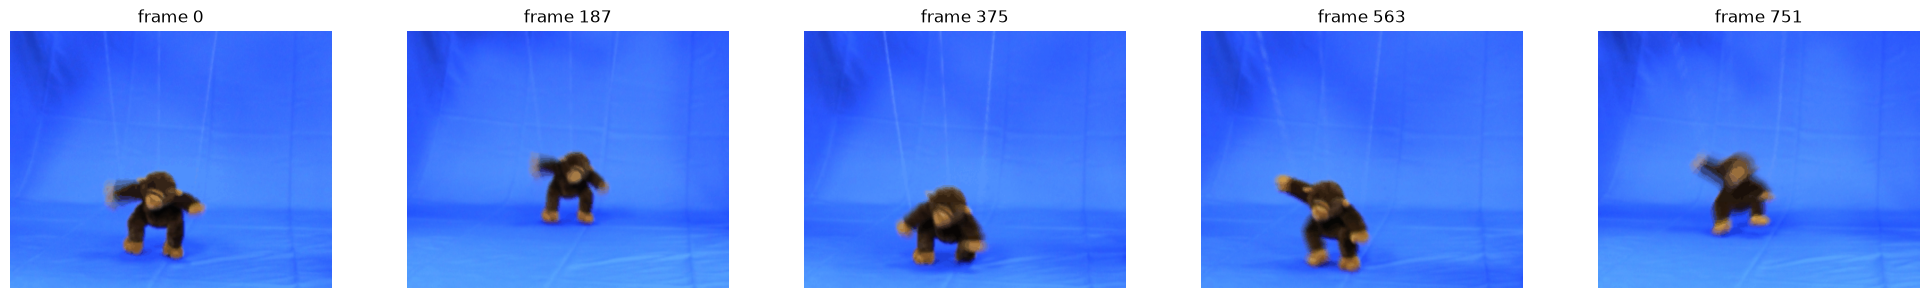

In [3]:
plot_samples(ORIGINAL_VIDEO, count = 5)

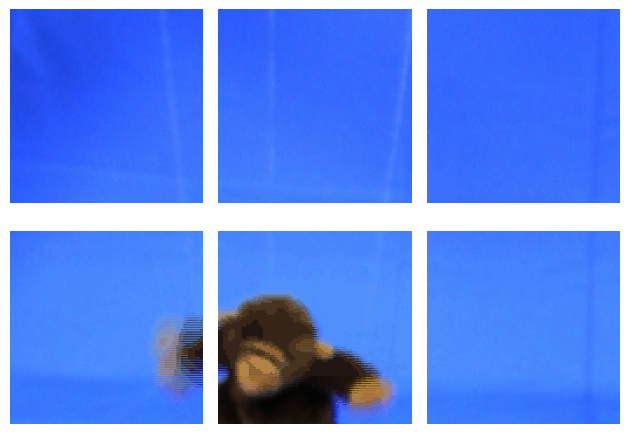

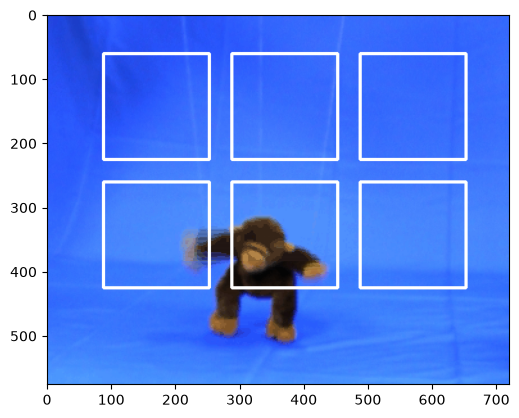

In [2]:
""" 
Steps:
- get macroblocks for some frame i
- 
"""

first_centre, last_centre, n_candidate_rows, n_candidate_cols, macroblocks = get_macroblocks(ORIGINAL_VIDEO, 0, 165, 200, 5)

#macroblocks - note: NOT CENTRED
#first_centre, last_centre, len(macroblocks), n_candidate_rows, n_candidate_cols
plot_macroblocks(macroblocks, n_candidate_rows, n_candidate_cols)
sample_0 = sample_ith_frame(ORIGINAL_VIDEO, 0)
macroblocks_drawn = draw_macroblocks(sample_0, None, macroblocks)
plt.imshow(macroblocks_drawn)

In [3]:
# get reports of consecutive frames i to i+n in bulk
consecutive_frames_in_macroblocks = get_macroblocks_consecutive_frames(ORIGINAL_VIDEO, count=2)

In [2]:
report, og, target, annotated = calculate_and_draw_search_motion_one_pair(ORIGINAL_VIDEO, None, 0, 165, 200, 5)
plot_frame_arr(zip(["Frame 0", "Frame 0+1", "Annotated Frame 0"], [og, target, annotated]) , 1)

Starting motion estimation between frame 0 and 1.
Getting macroblocks...
First valid centre: (142, 70)
Last valid centre: (542, 470)
Number of macroblocks: 9
Getting motion displacements for each block...
Getting best motion vector for block (142, 70)
Getting best motion vector for block (142, 270)
Getting best motion vector for block (142, 470)


KeyboardInterrupt: 